In [1]:
import os
from scipy.io import loadmat
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E9.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#tVec está en dias, lo pasamos a minutos
tVec_min = tVec*24*60
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
#print("Tabla xCellLog: \n", xCellLog)



Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False



/home/dacya-iagesbloom/.local/lib/python3.8/site-packages/pymoo/util/pruning_cd.py:24: RuntimeWarning: invalid value encountered in divide
  X = (X - min_vals) / (max_vals - min_vals)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      400 |     10 |             - |             -
     2 |      800 |     14 |  0.2500000000 |         ideal
     3 |     1200 |     17 |  0.0367099514 |             f
     4 |     1600 |     18 |  0.2000000000 |         ideal
     5 |     2000 |     20 |  0.0869565217 |         ideal
     6 |     2400 |     18 |  0.0569746906 |             f
     7 |     2800 |     22 |  0.2727272727 |         ideal
     8 |     3200 |     29 |  0.2004447424 |         nadir
     9 |     3600 |     33 |  0.2187500000 |         ideal
    10 |     4000 |     24 |  0.0535183154 |             f
    11 |     4400 |     27 |  0.1794871795 |         ideal
    12 |     4800 |     34 |  0.0487804878 |         ideal
    13 |     5200 |     22 |  0.0238095238 |         ideal
    14 |     5600 |     24 |  0.1044528009 |         nadir
    15 |     6000 |     31 |  0.0298397344 |         nadir
    16 |     6400 |     35 |  0.1428571429 |         ide

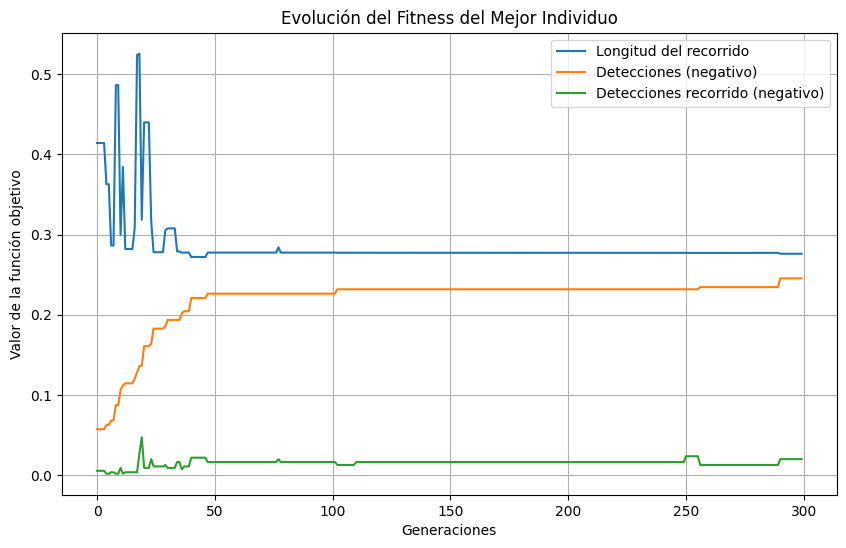

351


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.core.sampling import Sampling
from pymoo.core.population import Population
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.algorithms.moo.nsga2 import binary_tournament
from pymoo.operators.survival.rank_and_crowding.metrics import calc_crowding_distance
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.algorithms.soo.nonconvex.brkga import EliteSurvival

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

from pymoo.operators.survival.rank_and_crowding import RankAndCrowding
from pymoo.util.randomized_argsort import randomized_argsort
from pymoo.core.survival import Survival

from pymoo.termination.default import DefaultMultiObjectiveTermination


# === Muestreo personalizado ===

class CustomSampling(Sampling):
    def __init__(self, punto_ini, punto_fin):
        super().__init__()
        self.punto_ini = punto_ini
        self.punto_fin = punto_fin
        
    def _do(self, problem, n_samples, **kwargs):
        samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        #print(f"xl = {problema.xl} \n xu = {problema.xu}")
        for i in range(n_samples):
            sample = []
            sample.extend(self.punto_ini)
            #print(self.punto_ini)
            for j in range(3, problem.n_var-3, 3):  # Iterar en pasos de 3 (x, y, z)
                while True:  # Repetir hasta que la distancia mínima se cumpla
                    x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
                    y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
                    z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
                    nueva_pos = [x, y, z]
                    #print(f"nueva_pos = {nueva_pos}")
                    # Comprobar la distancia mínima entre la nueva partícula y las anteriores
                    dist_violada = False
                    for k in range(0, len(sample), 3):  # Revisar distancias con las partículas previas
                        if calcular_distancia(nueva_pos, sample[k:k+3]) <= problem.rango_deteccion:
                            dist_violada = True
                            break
                    
                    # Si no se viola la condición de distancia mínima, se agrega
                    if not dist_violada:
                        sample.extend(nueva_pos)
                        break
            sample.extend(self.punto_fin)
            samples[i] = sample  # Guardar el individuo generado
            #np.savetxt("sample.txt", samples)
        return samples

# === Cruce personalizado ===

class CustomCrossover(Crossover):
    def __init__(self, crossover_prob=0.5):
        super().__init__(2, 2)  # 2 padres -> 2 hijos
        self.crossover_prob = crossover_prob  # Probabilidad de cruce
        
    def _do(self, problem, X, **kwargs):
        _, n_matings, n_var = X.shape  # Dimensiones de los padres
        Y = np.full_like(X, np.nan)
        n_elite = 0
        n_no_elite = 0
        n_cruce = 0
        #print(f"Cruce a {X.shape}")
        #print(f"Población elite en el cruce {elite}")
        num_points = n_var // 3
        for i in range(n_matings):
            parent1, parent2 = X[0, i].copy(), X[1, i].copy()  
            # parent1 = parent1 + np.random.rand()
            # parent2 = parent2 + np.random.rand()
            # Verificar si los padres están en élite
            if any(np.array_equal(parent1, e) for e in elite) or any(np.array_equal(parent2, e) for e in elite):
                
                # Si alguno de los padres está en élite, pasa sin cambios
                if any(np.array_equal(parent1, e) for e in elite):
                    
                    #pasamos el padre 1 sin cruzar porque está en la élite
                    Y[0, i] = parent1

                    #Cruzamos el padre 1 (de la elite) con el padre 2 (no en la elite) para obtener el hijo2
                    child2 = np.copy(parent2)
                    
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child2[start:start+length] = parent1[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child2 = parent2.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[1, i] = child2
                    
                if any(np.array_equal(parent2, e) for e in elite):
                    #pasamos el padre 1 sin cruzar porque está en la élite
                    Y[1, i] = parent2

                    #Cruzamos el padre 1 (de la elite) con el padre 2 (no en la elite) para obtener el hijo2
                    child1= np.copy(parent1)
                    
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child1[start:start+length] = parent2[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child1 = parent1.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[0, i] = child1
            
            else:
                n_no_elite +=1
                # Aplicar cruce con probabilidad crossover_prob
                if np.random.rand() < self.crossover_prob:
                    n_cruce +=1
                    # Si se cruza, generar los hijos
                    child1, child2 = np.copy(parent1), np.copy(parent2)
    
                    # Limitar el punto de inicio del cruce para que no afecte la primera coordenada
                    # start debe ser un múltiplo de 3 (porque cada punto tiene 3 variables)
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child1[start:start+length] = parent2[start:start+length]
                        child2[start:start+length] = parent1[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child1, child2 = parent1.copy(), parent2.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[0, i] = child1
                    Y[1, i] = child2
                else:
                    # Si no se cruza, los hijos son idénticos a los padres
                    Y[0, i] = parent1
                    Y[1, i] = parent2

        # with open("crossover_output.txt", "w") as f:
        #     f.write("Padre 1".ljust(15) + "Padre 2".ljust(15) + "Hijo 1".ljust(15) + "Hijo 2".ljust(15) + "\n")
        #     f.write("=" * 60 + "\n")
        
        #     for i in range(n_matings):
        #         for j in range(n_var):
        #             f.write(f"{X[0, i, j]:<14.4f} {X[1, i, j]:<14.4f} {Y[0, i, j]:<14.4f} {Y[1, i, j]:<14.4f} \n")
        #         f.write("-" * 60 + "\n")

        
        return Y  # ¡IMPORTANTE! Siempre devolver Y

# === Mutación personalizada ===

class CustomMutation(Mutation):
    def __init__(self, prob=0.2, heavy_prob=0.015, lower=None, upper=None):
        super().__init__()
        self.prob = prob
        self.heavy_prob = heavy_prob
        self.lower = lower
        self.upper = upper
    def _do(self, problem, X, **kwargs):
        n_ind, n_var = X.shape  
        mutated_X = np.copy(X)
        n_mutations = 0
        #print("Mutación")
        #print(f"Mutación a {len(X)}")
        #print(f"Población elite en la mutacion {elite}")
        #print(f"Lower = {self.lower} \n Upper = {self.upper}")
        for i in range(n_ind):
            n_mutations +=1
            if any(np.array_equal(mutated_X[i], e) for e in elite):
                #print("ELITE EN MUTACION")
                continue  # Si el individuo está en élite, no se muta
            if np.random.rand() > self.prob:
                continue #Si el número generado es mayor que la probabilidad de mutación, ese individuo no muta
            # Aplicamos mutación con probabilidad `self.prob`
            mask = np.random.rand(n_ind, n_var) < self.prob #Se crea una máscara para que, en caso de que ese individuo mute, luego cada gen tenga una probabilidad de mutación
            mask_heavy_mutation = np.random.rand(n_ind, n_var) < self.heavy_prob
            mask[:, :3] = False
            mask[:, -3:] = False
            mask_heavy_mutation[:, :3] = False
            mask_heavy_mutation[:, -3:] = False
            mask_combined = mask | mask_heavy_mutation
            noise = np.random.randn(n_ind, n_var) * problema.rango_deteccion  # Ruido gaussiano
            heavy_noise = np.random.randn(n_ind, n_var) * problem.rango_deteccion * 100
            final_noise = np.zeros((n_ind, n_var))
            final_noise[mask] = noise[mask]
            final_noise[mask_heavy_mutation] = heavy_noise[mask_heavy_mutation]
            mutated_X[mask_combined] += final_noise[mask_combined]

        # with open("mutacion_output.txt", "w") as f:
        #     f.write("Individuo | Variable | Mascara | Mascara heavy | Original | Mutado | Noise \n")
        #     f.write("-" * 90 + "\n")

        #     for w in range(n_ind):
        #         for j in range(n_var):
        #             f.write(f"{w+1:<9} | {j+1:<8} | {int(mask[w,j]):<7} | {int(mask_heavy_mutation[w,j]):<13} | {X[w, j]:<10.4f} | {mutated_X[w, j]:<10.4f} | {final_noise[w,j]:<8.4f}\n")
        #         f.write("\n")  # Separación entre individuos
        #print(f"N_mutations = {n_mutations}\n Poblacion mutada = {mutated_X.shape}")
        return mutated_X



# === Función para calcular la distancia Euclidiana en 3D === #

def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)
    
# # === Función para eliminar partículas dentro del rango de detección ===

def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, indices_eliminadas):
    # Convertir centro en array numpy
    centro = np.array(centro[:2])
    
    # Inicializar distancias con un valor alto
    distancias = np.full(mapa.shape[0], 9999.675)  
    
    # Filtrar solo los valores válidos
    mascara_validas = (indices_eliminadas == 0)
    mascara_detectadas = (indices_eliminadas == 1)
    
    #print(f"Distancias shape antes = {distancias.shape}")  # Debe ser (550,)
    
    # Calcular solo para las partículas válidas
    distancias[mascara_validas] = np.linalg.norm(mapa[mascara_validas, :2] - centro[:2], axis=1)
    
    #print(f"Distancias shape después = {distancias.shape}")  # Debe seguir siendo (550,)
    
    # Aplicar lo mismo para distancias_repetidas
    distancias_repetidas = np.full(mapa.shape[0], 9999.675)
    distancias_repetidas[mascara_detectadas] = np.linalg.norm(mapa[mascara_detectadas, :2] - centro[:2], axis=1)

    #print(f"Mapa shape = {mapa.shape}")  # (550, 3)
    
    # Encontrar las partículas dentro del rango de detección
    indices_detectados[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion).astype(int)
    indices_eliminadas[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion*3).astype(int)
    
    #print(f"indices_detectados shape = {indices_detectados.shape}")  # (550,)
    
    # Imprimir solo las distancias menores al rango de detección
    #print(distancias[indices_detectados.astype(bool)])
    
    return indices_detectados, indices_eliminadas
# === Problema de optimización ===
class OptimizacionConDeteccion(ElementwiseProblem):
    def __init__(self, mapa_particulas, n_puntos=8, rango_deteccion=5, max_dist=1000, v_media=1):
        self.mapa_particulas = mapa_particulas  # Partículas en 3D
        self.rango_deteccion = rango_deteccion
        self.n_puntos = n_puntos
        self.max_dist = max_dist
        self.v_media = v_media
        self.xl = np.array([-600, -400, -20])
        self.xu = np.array([600, 200, 0])
        self.mejor_fitness = float('inf')  # Inicializa como un valor muy alto
        self.mejor_deteccion = 0
        self.mapa_dinamico_mejor = None  # Para guardar el mejor mapa dinámico
        self.mejor_individuo = None
        self.long_max = calcular_distancia(self.xl[:2], self.xu[:2]) #Calculamos la longitud máxima para normalizar las longitudes
        self.indice_tVec_ant = 0
        # Definir el número de variables como el número de puntos de paso (n_puntos * 3 coordenadas)
        super().__init__(n_var=n_puntos*3, 
                         n_obj=3, 
                         n_constr=0, 
                         xl=np.tile(self.xl, n_puntos), 
                         xu=np.tile(self.xu, n_puntos))

    def _evaluate(self, x, out, *args, **kwargs):
        # x contiene los índices de las partículas ordenadas para el recorrido
        recorrido = [x[i:i+3] for i in range(0, len(x), 3)]

        # Longitud total del recorrido
        longitud_recorrido = 0
        penalty = 0
        mov=0
        longitudes=[]
        num_interpolacion = 5
        detecciones_totales = 0
        #detecciones_totales = [np.zeros(len(self.mapa_particulas[1]))]
        repetidas_totales = 0
        tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
        indices_detectados = np.zeros(len(self.mapa_particulas[1]))
        indices_eliminadas = np.zeros(len(self.mapa_particulas[1]))
        pesos_gaussianos_i =  np.zeros(len(self.mapa_particulas[1]))
        aportaciones = np.zeros(len(self.mapa_particulas[1]))
        indices_repetidas = np.zeros(len(self.mapa_particulas[1])) 
        t_medida_ant = 8 #min
        detecciones_recorrido = 0
        # Iterar sobre el recorrido y calcular la longitud total
        for i in range(len(recorrido)):
            deteccion = 0
            if (i==0):
                p2 = recorrido[i]
            else:
                p1 = recorrido[i-1]
                p2 = recorrido[i]
                longitud_recorrido += calcular_distancia(p1, p2)

            tAct = tiempo + longitud_recorrido/(self.v_media*60)+t_medida_ant*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
            dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
            indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
            
            #print(f"tAct: {tAct}, tVec: {tVec_min}")
            #print(f"Diferencia absoluta: {dif_tVec_tAct}")
            #print(f"Índice del valor más cercano: {indice_tVec}")
            
            #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
            #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
            if(indice_tVec != self.indice_tVec_ant):
                #Creamos un diccionario de detecciones
                id_detectados = {id_: det for id_, det in zip(IDLogs[self.indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
                id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
                indices_detectados = (id_detectados_t2 > 0).astype(int)
            # Actualizar el mapa y contar las partículas detectadas
            
            indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, self.rango_deteccion, indices_detectados, indices_eliminadas)

            self.indice_tVec_ant = indice_tVec

            if i != 0:
                for i in range(len(recorrido)):
                    if i!= 0:
                        p1, p2 = recorrido[i-1], recorrido[i]
                    
                        # Definir la elipse
                        a = calcular_distancia(p1, p2) / 2  # Semieje mayor (mitad del segmento)
                        #b = min(problema.rango_deteccion, a)  # Semieje menor (máximo hasta el radio de detección)
                        b = 0.05
                        centro_elipse = (np.array(p1) + np.array(p2)) / 2  # Centro de la elipse
                    
                        particulas_en_elipse = 0
                        for particula in xCellLog[indice_tVec, :, :]:
                            # Ecuación de la elipse: ((x - h)^2 / a^2) + ((y - k)^2 / b^2) <= 1
                            if ((particula[0] - centro_elipse[0])**2 / a**2 + (particula[1] - centro_elipse[1])**2 / b**2) <= 1:
                                particulas_en_elipse += 1
                    
                        detecciones_recorrido += particulas_en_elipse
            
                        
        
        detecciones_totales = np.sum(indices_detectados)
        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        out["F"] = [longitud_recorrido/(self.n_puntos*calcular_distancia(problema.xl, problema.xu)), -1.5*detecciones_totales/problema.mapa_particulas.shape[1], -detecciones_recorrido/problema.mapa_particulas.shape[1]]  # Usamos -detecciones_totales para maximizar. Normalizamos las detecciones con el n máx de partículas y la longitud con la longitud máxima de la población
        #out["G"] = [g]

convergence = []
elite = []
def callback(algorithm):
    global elite
    gen = algorithm.n_gen
    pop = algorithm.pop
    F = pop.get("F")  # Obtener valores de función objetivo de la población
    rank = pop.get("rank")
    
    # Obtener el mejor (mínimo) valor de cada función objetivo
    best_fitness_detecc_ind = np.argmin(F[:,1])
    best_fitness = F[best_fitness_detecc_ind] 

    # Guardar el mejor fitness de cada generación
    convergence.append(best_fitness)

    elite_indices =  np.argsort(rank)
    
    elite_individuals = [pop[i] for i in elite_indices[:50]]  # Seleccionamos los 5 mejores
    # Guardar los valores de decisión (variables de diseño) de los individuos élite
    elite = [ind.X.copy() for ind in elite_individuals]
    #print(f"Elite pop = {len(elite)}")
    
# Crear el problema de optimización
problema = OptimizacionConDeteccion(xCellLog)
pop_size = 400



# Crear el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=pop_size,
    #n_offsprings=10,
    selection=TournamentSelection(func_comp=binary_tournament),
    survival=RankAndCrowding(crowding_func = "pcd"),
    crossover=CustomCrossover(),
    mutation=CustomMutation(lower = problema.xl, upper = problema.xu),
    sampling=CustomSampling(punto_ini =[-600, -400, -15], punto_fin = [-500, -300, -15]),
    #mutation=PM(prob=0.2, eta=10),
    eliminate_duplicates=True,
    callback = callback
)
algorithm.callback = callback
termination = DefaultMultiObjectiveTermination(
    xtol=1e-5,
    cvtol=1e-6,
    ftol=0.0025,
    period=30,
    n_max_gen=300,
    n_max_evals=1000000
)

# Ejecutar la optimización
result = minimize(
    problema,
    algorithm,
    termination,
    seed=42,
    verbose=True,
    save_history=True,
    callback=callback
)

n_evals = np.array([e.evaluator.n_eval for e in result.history])
opt = np.array([e.opt[0].F for e in result.history])

convergence = np.array(convergence)

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)")
plt.plot(-convergence[:, 2], label="Detecciones recorrido (negativo)")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

print(len(result.F))

In [16]:
convergence.shape

(300, 3)

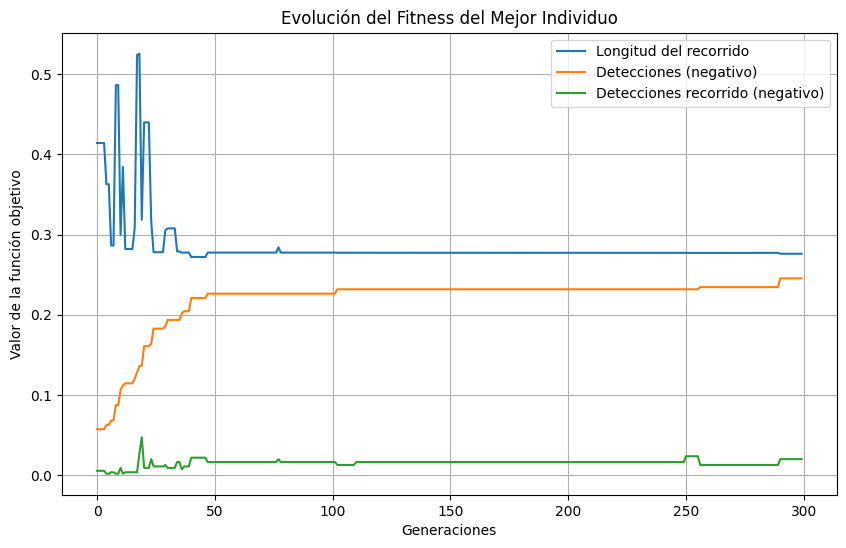

In [17]:
# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)")
plt.plot(-convergence[:, 2], label="Detecciones recorrido (negativo)")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

In [4]:
np.savetxt("X_ruta_larga_M9_300gen_400pop.txt", result.X)
np.savetxt("Convergencia_ruta_larga_M9_300gen_400pop.txt", convergence)

Hipervolumen: 1.7447290265550246
Soluciones del frente = (351, 3)


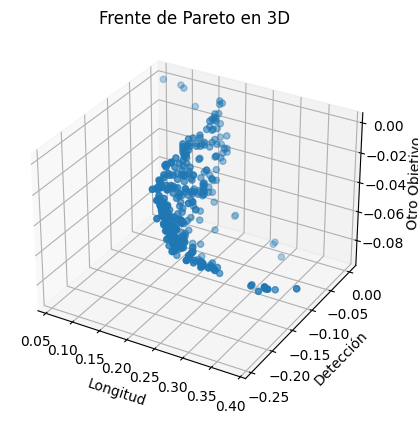

In [5]:
from pymoo.indicators.hv import HV
# Punto de referencia para el cálculo del hipervolumen (debe ser peor que todas las soluciones)
ref_point = np.array([max(result.F[:, 0]), max(result.F[:, 1]), max(result.F[:, 2])]) + 1

# Calcular hipervolumen
hv = HV(ref_point=ref_point)
hypervolume = hv(result.F)

print(f"Hipervolumen: {hypervolume}")
print(f"Soluciones del frente = {result.F.shape}")
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(result.F[:, 0], result.F[:, 1], result.F[:, 2])

ax.set_xlabel("Longitud")
ax.set_ylabel("Detección")
ax.set_zlabel("Otro Objetivo")  # Cambia esto según tu tercer objetivo
ax.set_title("Frente de Pareto en 3D")

plt.show()


## SELECCION DEL INDIVIDUO FINAL DE DIFERENTES FORMAS

SUMA PONDERADA

In [20]:
result.F

array([[ 0.30438401, -0.03      , -0.09090909],
       [ 0.38516469, -0.10636364, -0.08363636],
       [ 0.2854025 , -0.02454545, -0.08545455],
       ...,
       [ 0.21433825, -0.19636364, -0.02181818],
       [ 0.26771648, -0.22909091, -0.03636364],
       [ 0.20082777, -0.03      , -0.01818182]])

In [18]:
best_idx = np.argmin(result.F[:, 1])  # Encuentra el índice del menor valor en la columna 1
mejor_individuo = result.X[best_idx]  # Extrae la solución correspondiente
print(f"Best idx = {best_idx}")
# weights = np.array([0.2, 0.6, 0.2])  # Ajusta según tus preferencias
# scores = (result.F * weights).sum(axis=1)  # Calcula la función agregada
# best_idx = np.argmin(scores)  # Minimización
# mejor_individuo = result.X[best_idx]


#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
for i in range(2, len(mejor_individuo), 3):
    #print(i)
    mejor_individuo[i]=-15

recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
indices_detectados_ant = np.zeros(len(problema.mapa_particulas[1]))
indices_eliminadas = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0
t_medida = 8 #min
for i in range(len(recorrido)):
    deteccion = 0
    if (i==0):
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
        
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)+t_medida*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    
    #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
    #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
    if(indice_tVec != problema.indice_tVec_ant):
        #Creamos un diccionario de detecciones
        id_detectados = {id_: det for id_, det in zip(IDLogs[problema.indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
        id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
        indices_detectados = (id_detectados_t2 > 0).astype(int)
    # Actualizar el mapa y contar las partículas detectadas
    
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, problema.rango_deteccion, indices_detectados, indices_eliminadas)

    problema.indice_tVec_ant = indice_tVec
    mapa_dinamico_detecciones[i] = indices_detectados
    #print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
#print(f"Detecciones totales = {detecciones_totales}")
#print(f"Tiempo total = {(tAct-tiempo)*60}")

Best idx = 242



Mapa número = 0


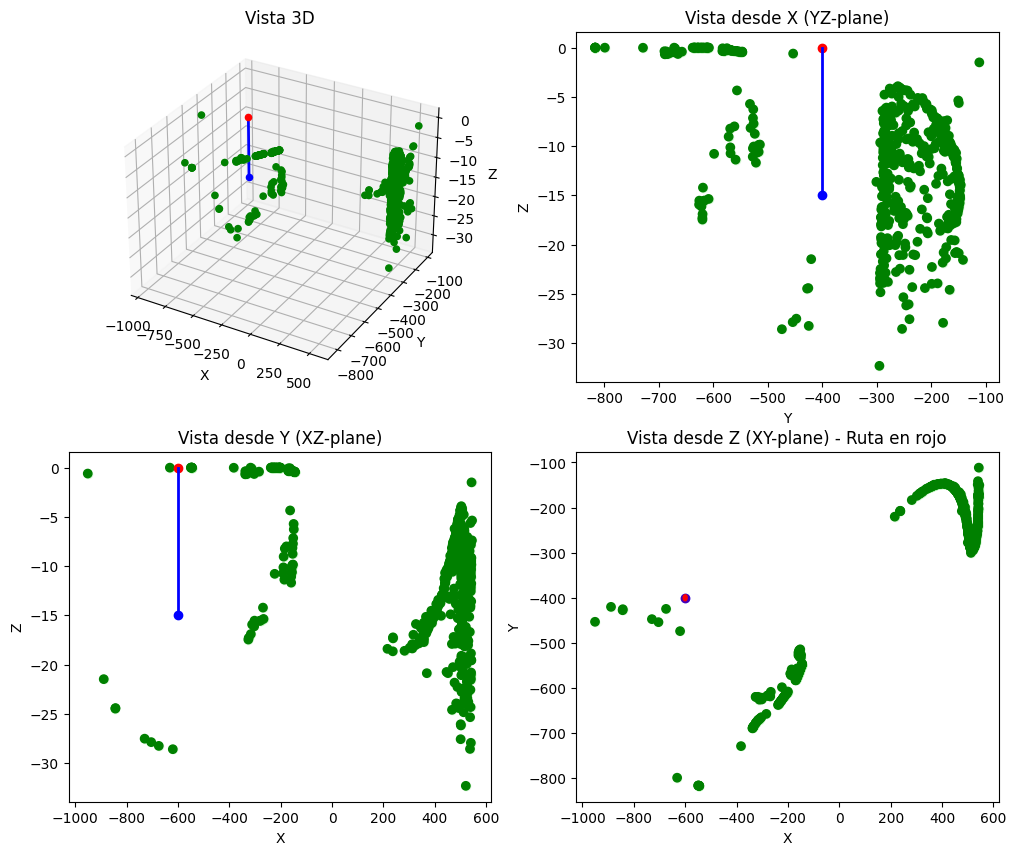


Mapa número = 2


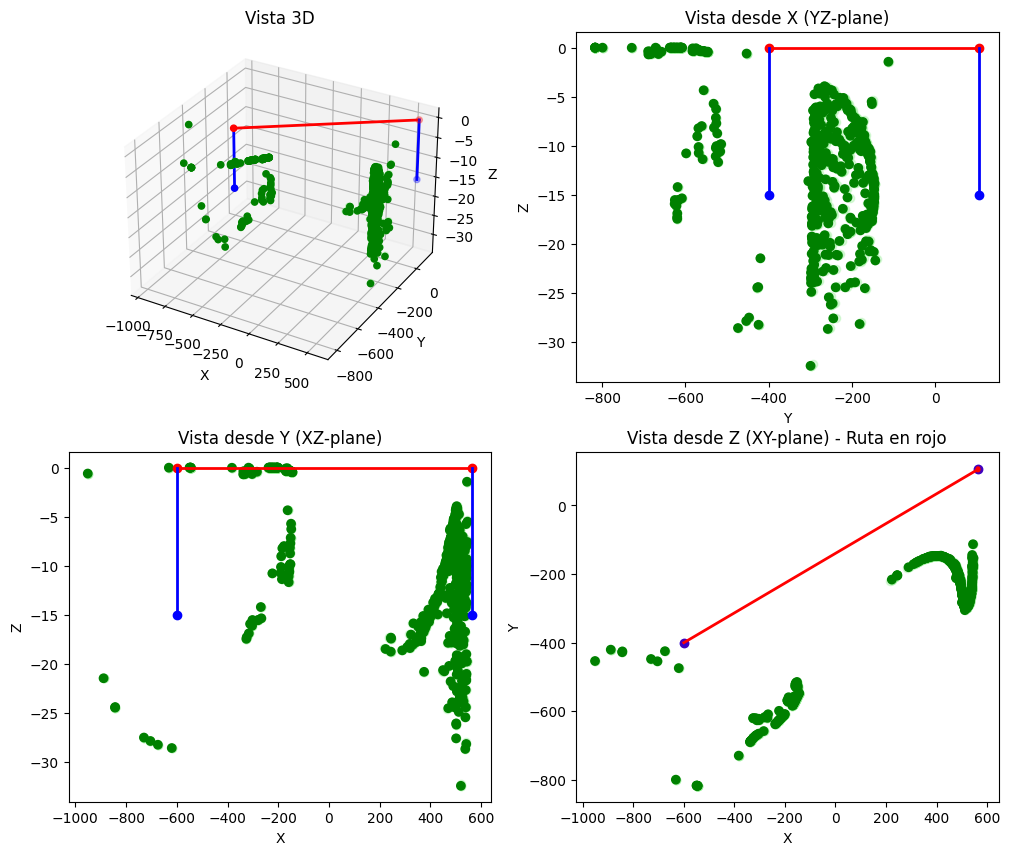


Mapa número = 2


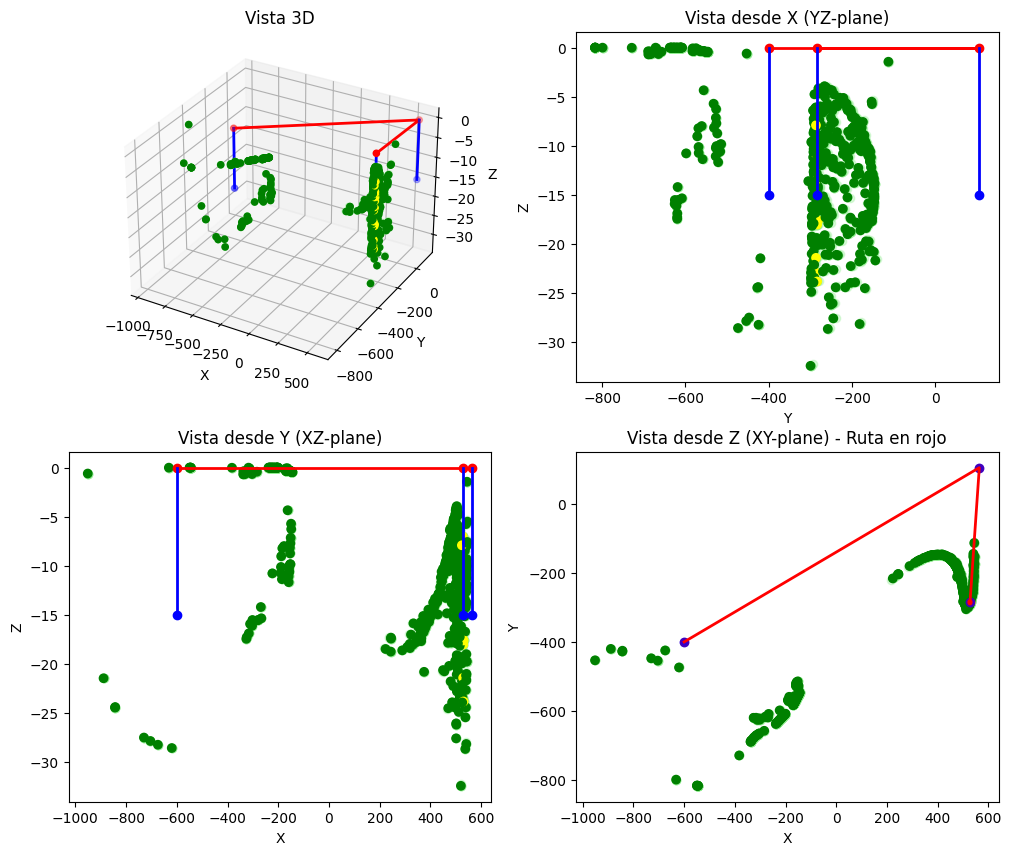


Mapa número = 3


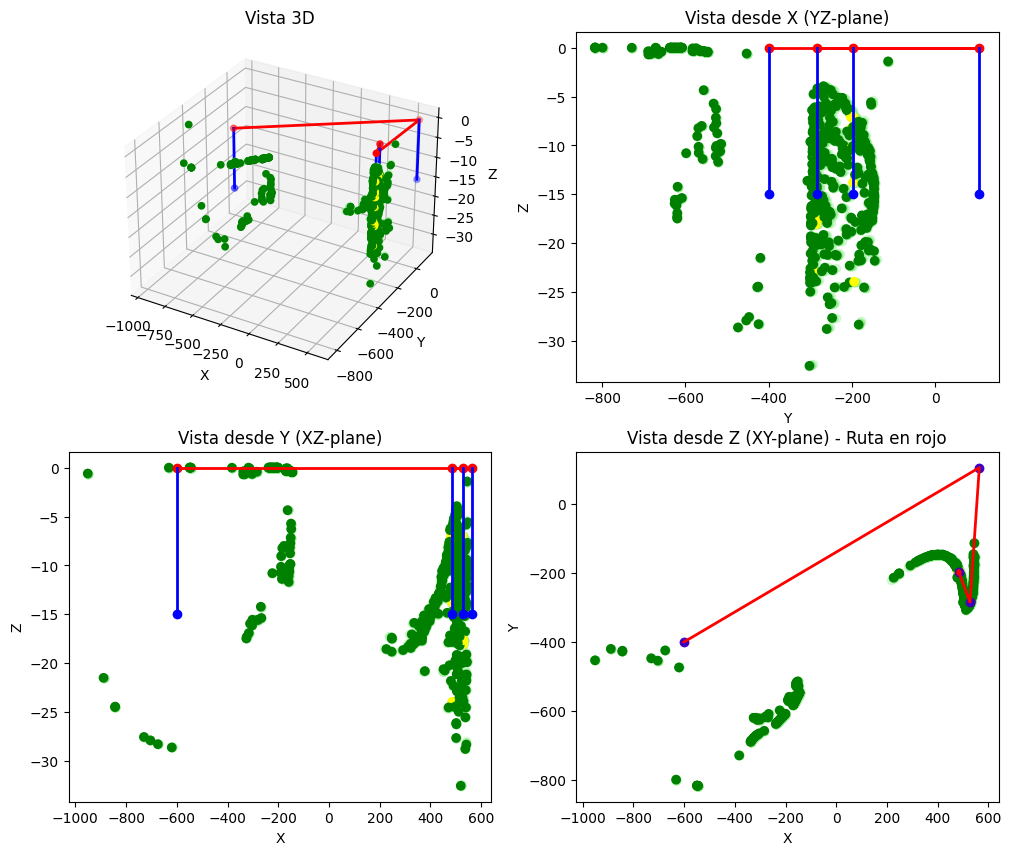


Mapa número = 3


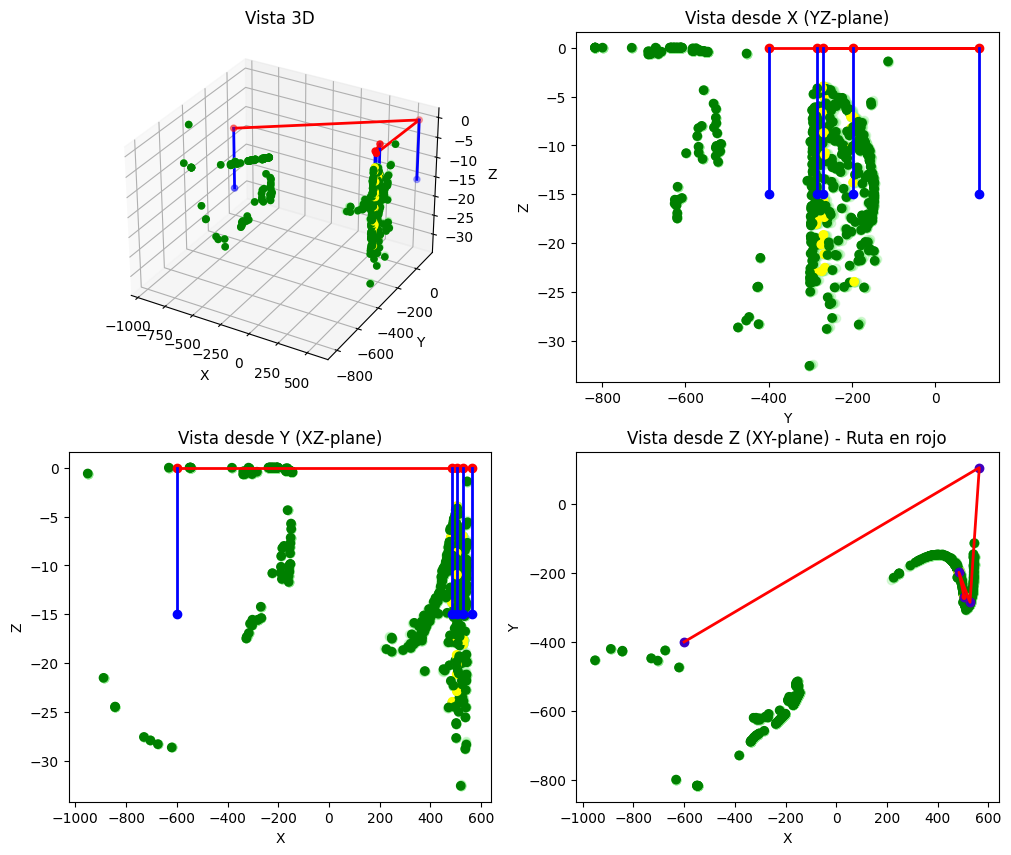


Mapa número = 3


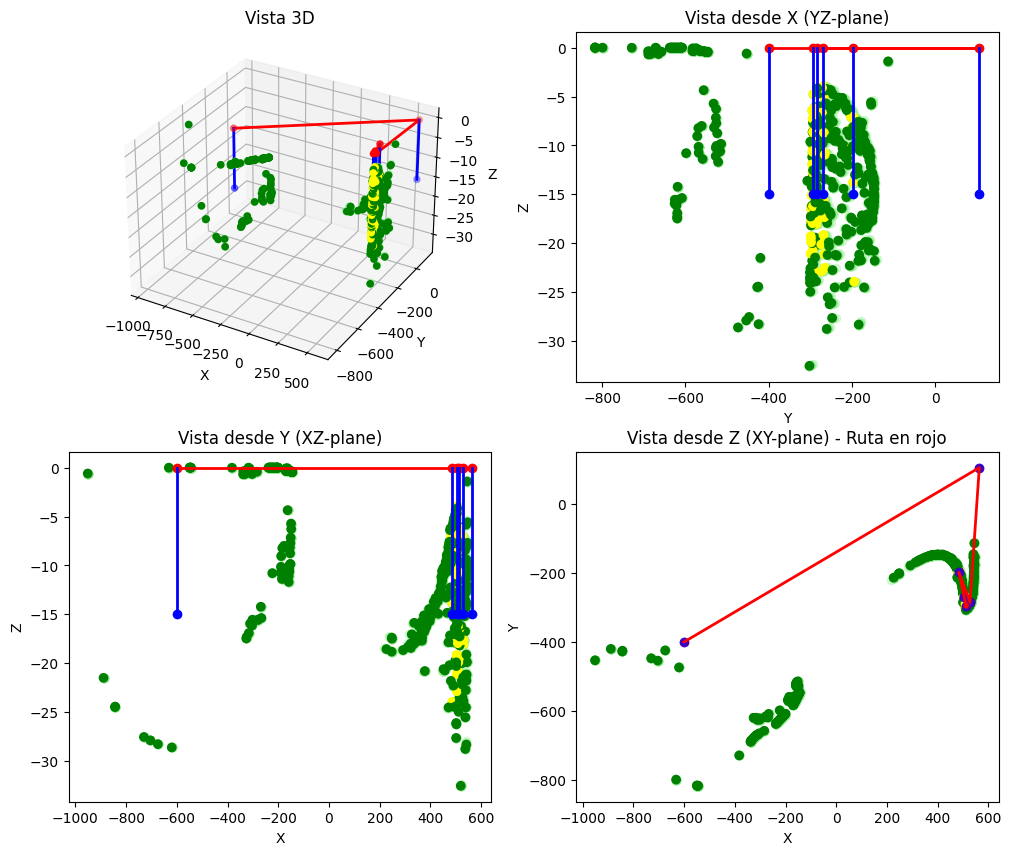


Mapa número = 4


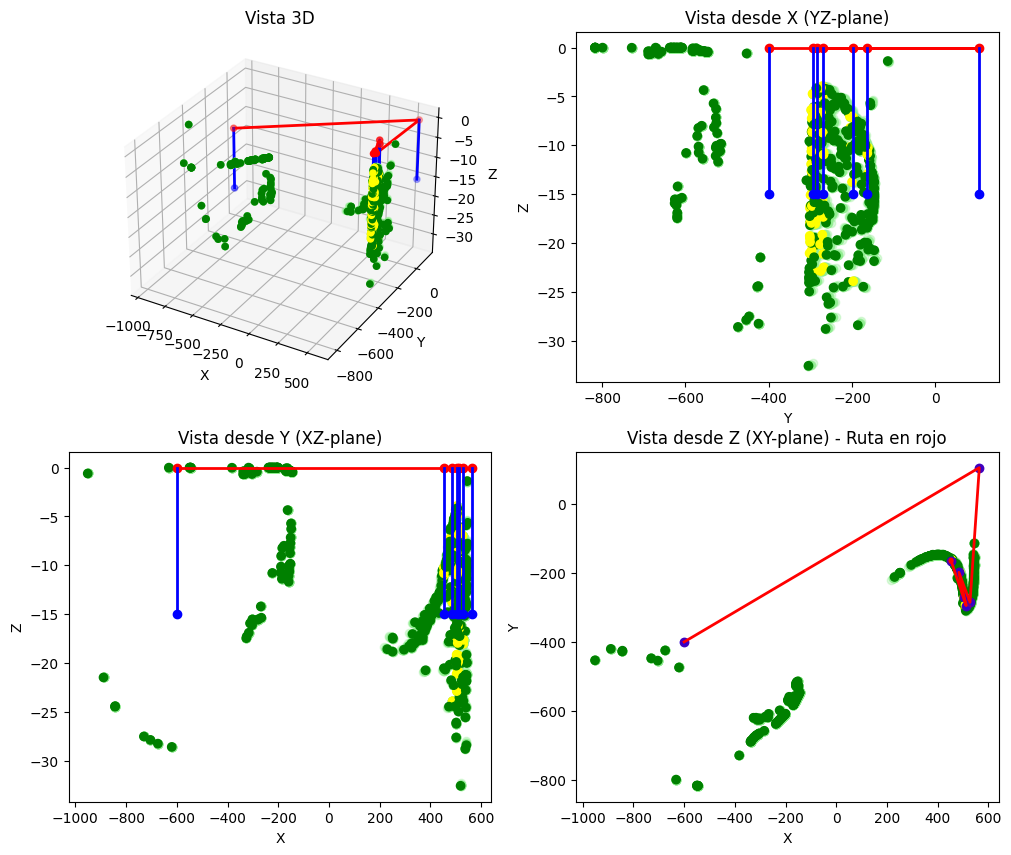


Mapa número = 5


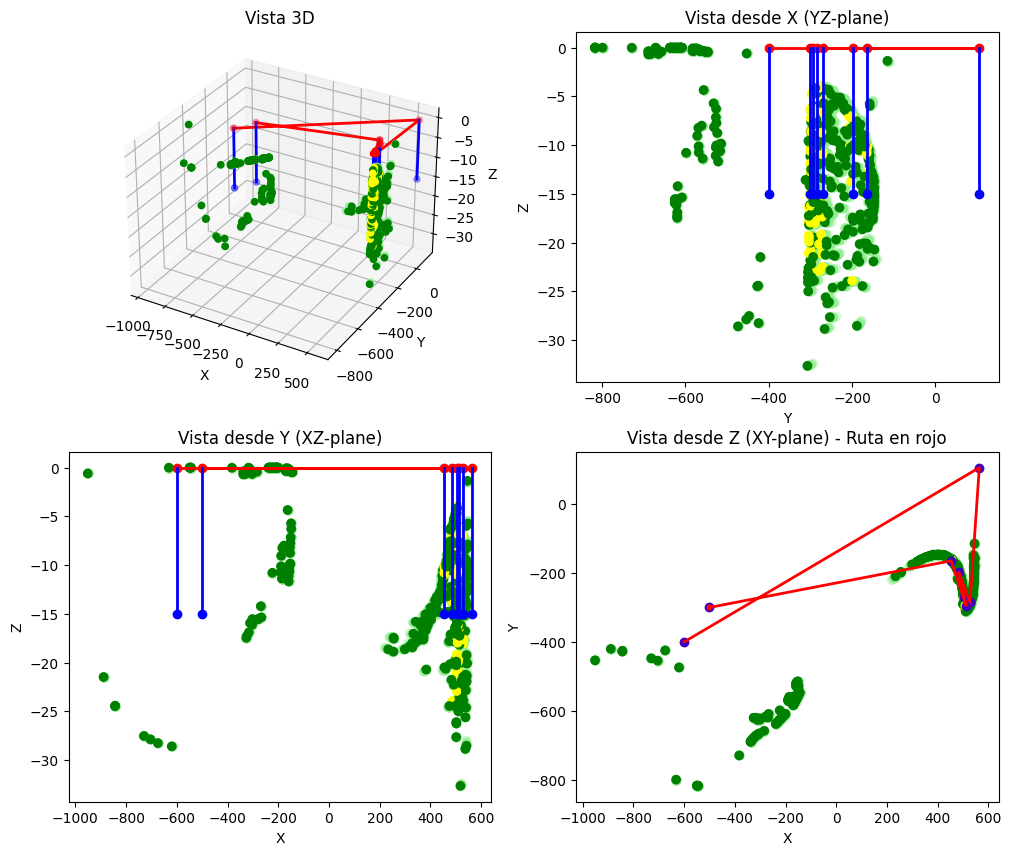

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [15]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []
longitud_recorrido = 0

# Listas para almacenar partículas de instantes anteriores
historico_x = []
historico_y = []
historico_z = []

for i in range(len(recorrido)):
    if i == 0:
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
    zeros.append(0)
    tAct = tiempo + longitud_recorrido / (problema.v_media * 60) + t_medida * (i + 1)
    dif_tVec_tAct = np.abs(tVec_min - tAct)
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"")
    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]
    print(f"Mapa número = {indice_tVec}")
    # Guardar en el histórico
    historico_x.append(map_x)
    historico_y.append(map_y)
    historico_z.append(map_z)
    
    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])
    
    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))
    
    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax1.scatter(historico_x[h], historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')
    ax1.scatter(x, y, zeros, c='r', marker='o')
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")
    
    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    for h in range(len(historico_y)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_y))
        ax2.scatter(historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")
    
    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax3.scatter(historico_x[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")
    
    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax4.scatter(historico_x[h], historico_y[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha=0.2)
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)
    radio = 5
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)
    # for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
    #     ax4.text(xi, yi, str(idx), color='blue', fontsize=12, fontweight='bold')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")

    # if(i < len(tiempos_ruta)-1 ):
    #     ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
    #     ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    # else:
    #     ax4.set_xlim(min(x[0] - 100, min(x)), max(x[0] + 100, max(x)))
    #     ax4.set_ylim(min(y[0] - 100, min(y)), max(y[0] + 100, max(y)))

    # # ax4.set_xlim(-200, 50)
    # # ax4.set_ylim(-200, -50)  
    
    plt.show()
    plt.pause(0.1)
    
    j += 3

tiempos_ruta


In [12]:

weights = np.array([0.25, 0.65, 0.1])  # Ajusta según tus preferencias
scores = (result.F * weights).sum(axis=1)  # Calcula la función agregada
best_idx = np.argmin(scores)  # Minimización
mejor_individuo = result.X[best_idx]


#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
for i in range(2, len(mejor_individuo), 3):
    #print(i)
    mejor_individuo[i]=-15

recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
indices_detectados_ant = np.zeros(len(problema.mapa_particulas[1]))
indices_eliminadas = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0
t_medida = 8 #min
for i in range(len(recorrido)):
    deteccion = 0
    if (i==0):
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
        
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)+t_medida*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    
    #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
    #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
    if(indice_tVec != problema.indice_tVec_ant):
        #Creamos un diccionario de detecciones
        id_detectados = {id_: det for id_, det in zip(IDLogs[problema.indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
        id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
        indices_detectados = (id_detectados_t2 > 0).astype(int)
    # Actualizar el mapa y contar las partículas detectadas
    
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, problema.rango_deteccion, indices_detectados, indices_eliminadas)

    problema.indice_tVec_ant = indice_tVec
    mapa_dinamico_detecciones[i] = indices_detectados
    #print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
#print(f"Detecciones totales = {detecciones_totales}")
#print(f"Tiempo total = {(tAct-tiempo)*60}")

indice_tVec = 0
Tiempo de la ruta (s): 480.0
Tiempo del tramo (s): 1558.0433134346117
Longitud recorrido (m): 0
INDICES DETECTADOS = 0.0


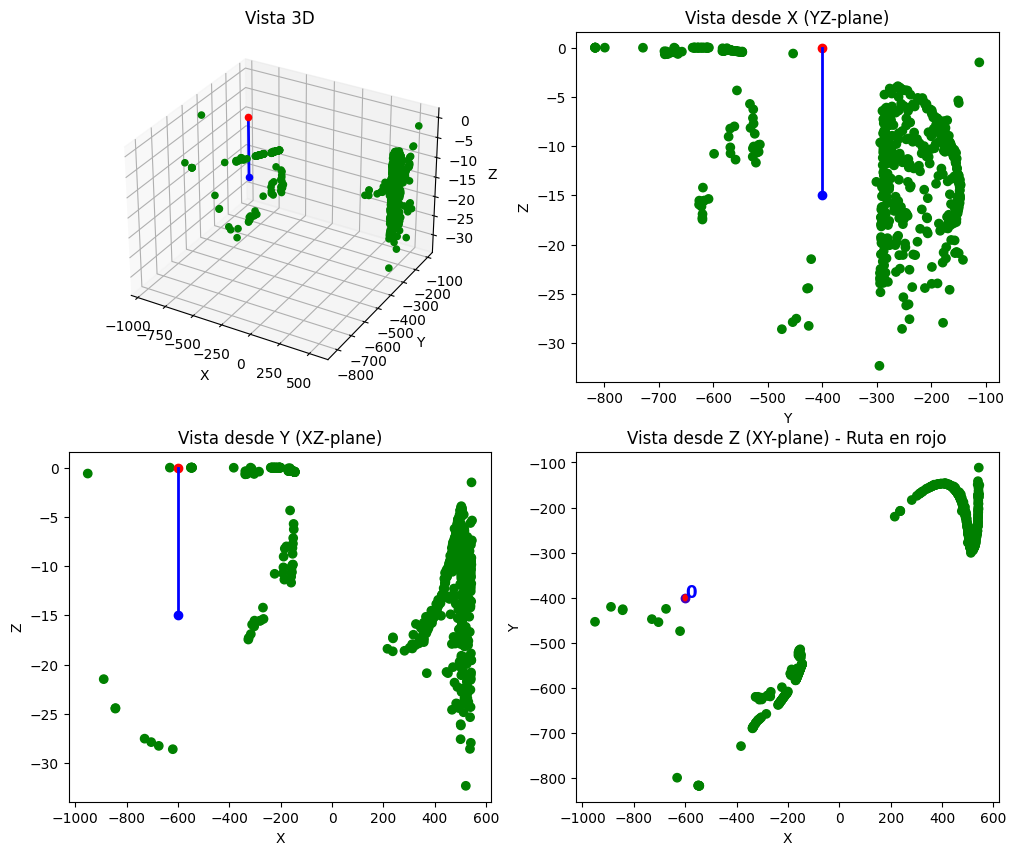

indice_tVec = 1
Tiempo de la ruta (s): 1818.771435548806
Tiempo del tramo (s): 1338.7714355488592
Longitud recorrido (m): 858.7714355488594
INDICES DETECTADOS = 0.0


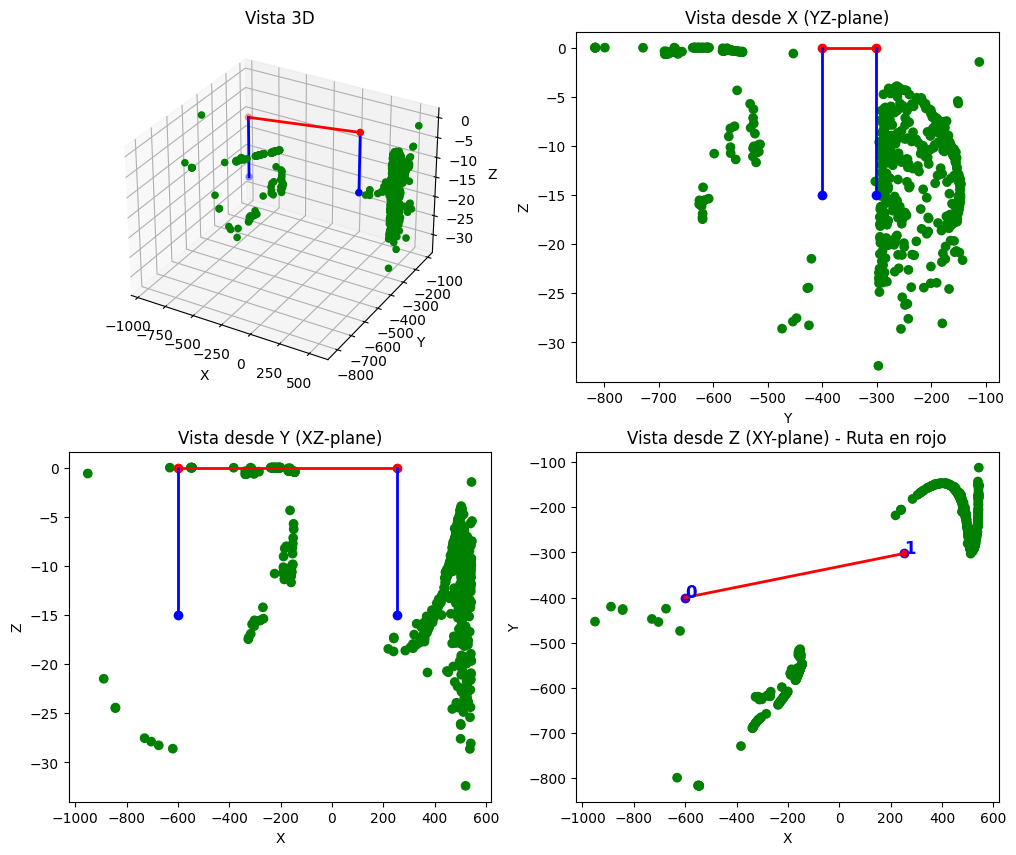

indice_tVec = 2
Tiempo de la ruta (s): 2573.328528220154
Tiempo del tramo (s): 754.5570926712913
Longitud recorrido (m): 1133.3285282201507
INDICES DETECTADOS = 18.0


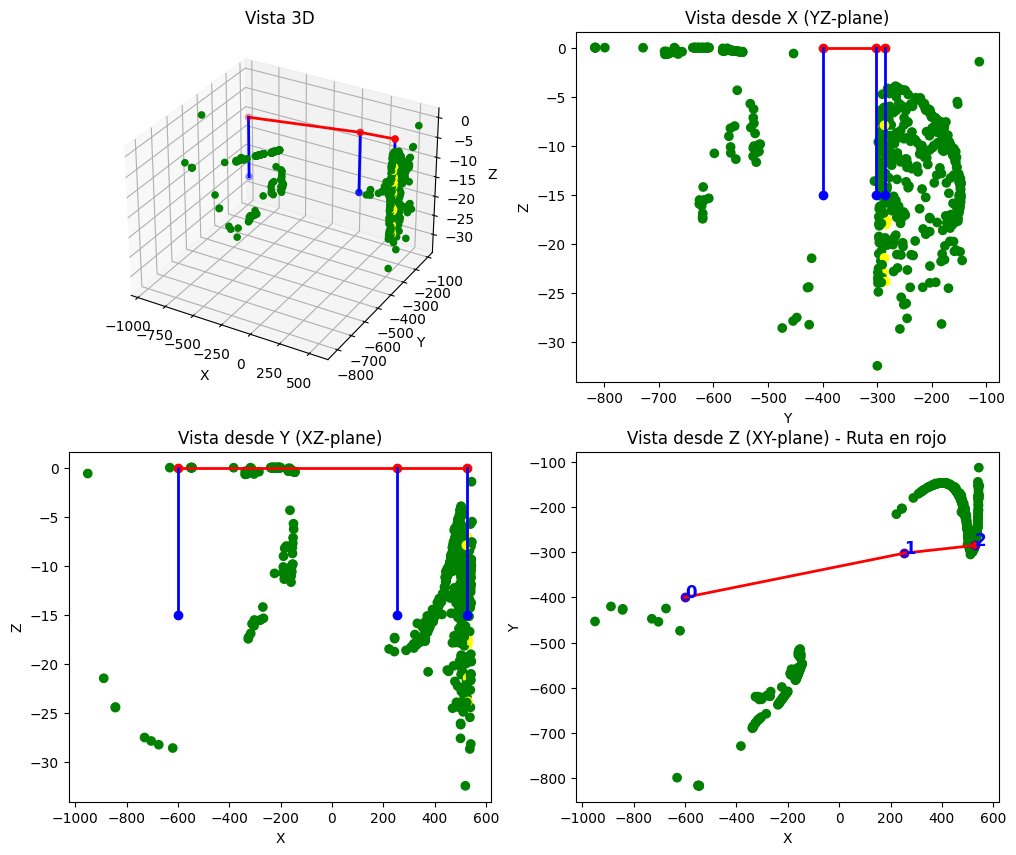

indice_tVec = 2
Tiempo de la ruta (s): 3150.638996497837
Tiempo del tramo (s): 577.3104682776786
Longitud recorrido (m): 1230.6389964978293
INDICES DETECTADOS = 25.0


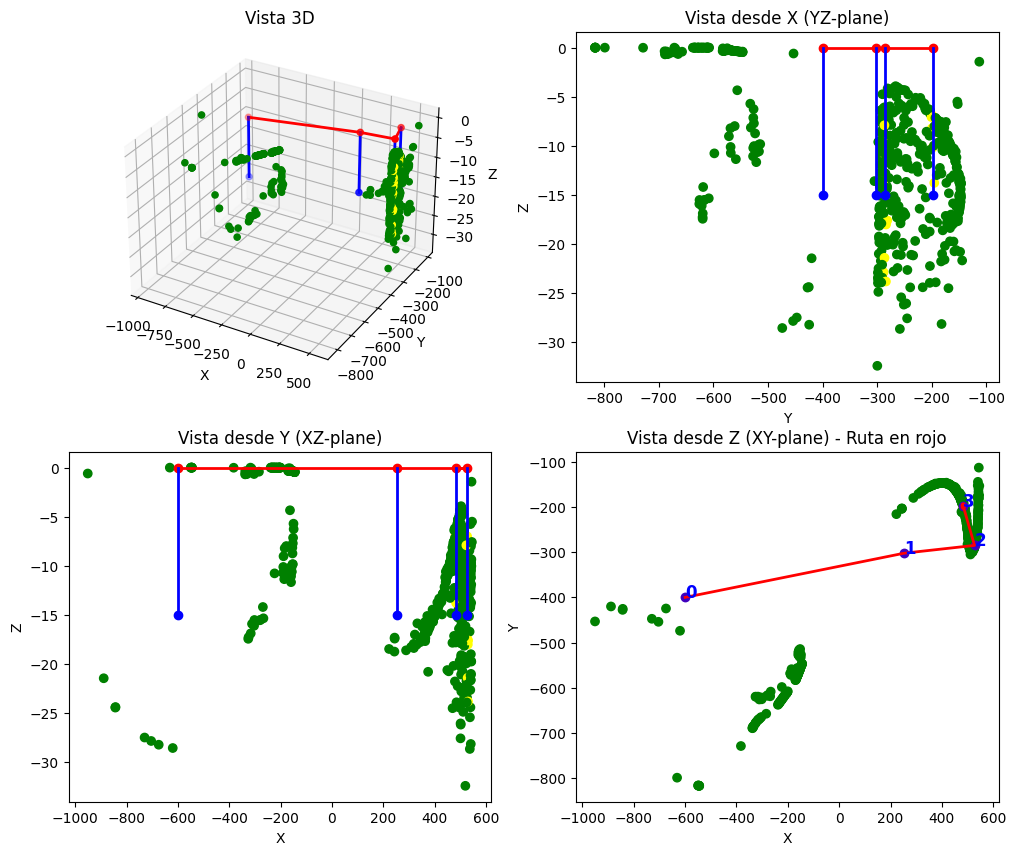

indice_tVec = 3
Tiempo de la ruta (s): 3704.7384362415323
Tiempo del tramo (s): 554.0994397436751
Longitud recorrido (m): 1304.7384362415044
INDICES DETECTADOS = 37.0


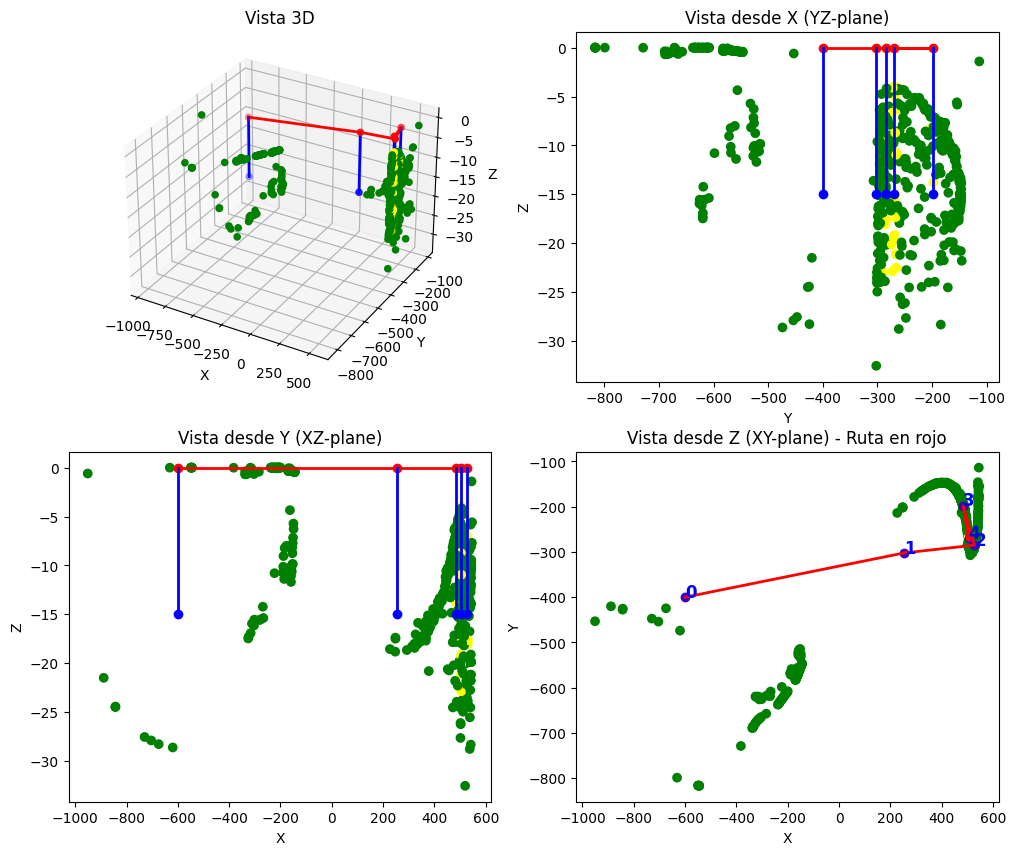

indice_tVec = 3
Tiempo de la ruta (s): 4211.3157376925665
Tiempo del tramo (s): 506.5773014511126
Longitud recorrido (m): 1331.315737692617
INDICES DETECTADOS = 72.0


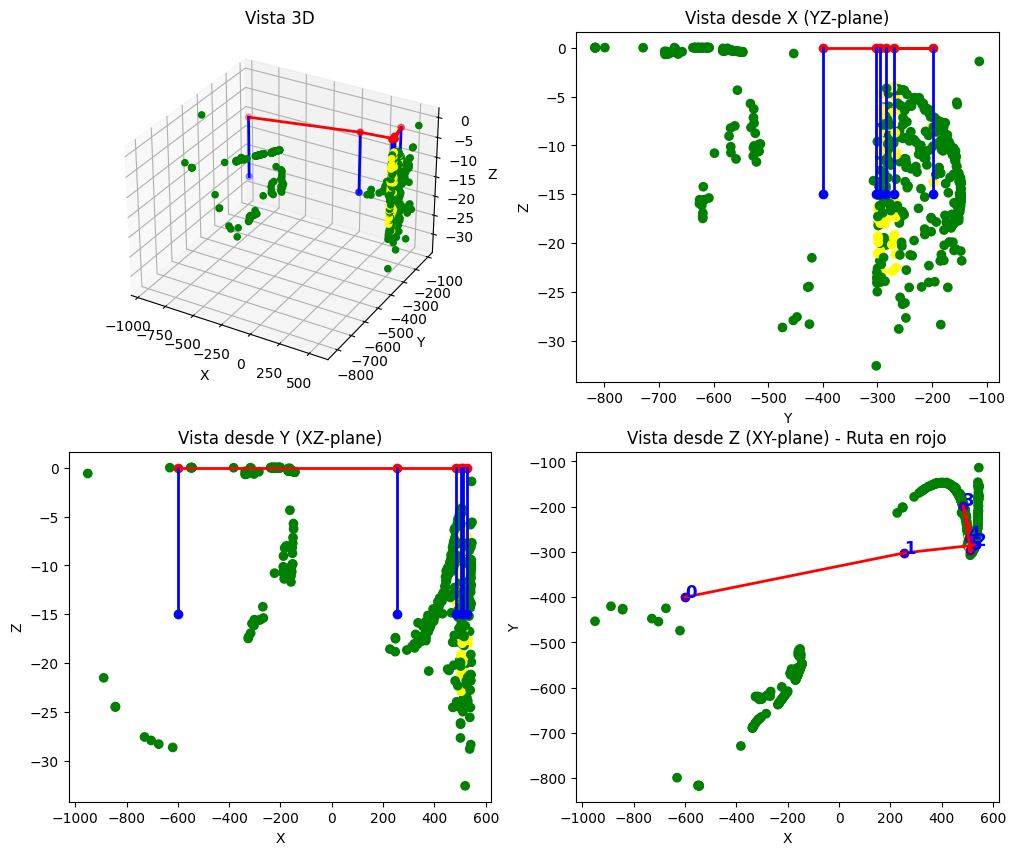

indice_tVec = 3
Tiempo de la ruta (s): 4834.206842737003
Tiempo del tramo (s): 622.8911050443741
Longitud recorrido (m): 1474.206842736991
INDICES DETECTADOS = 83.0


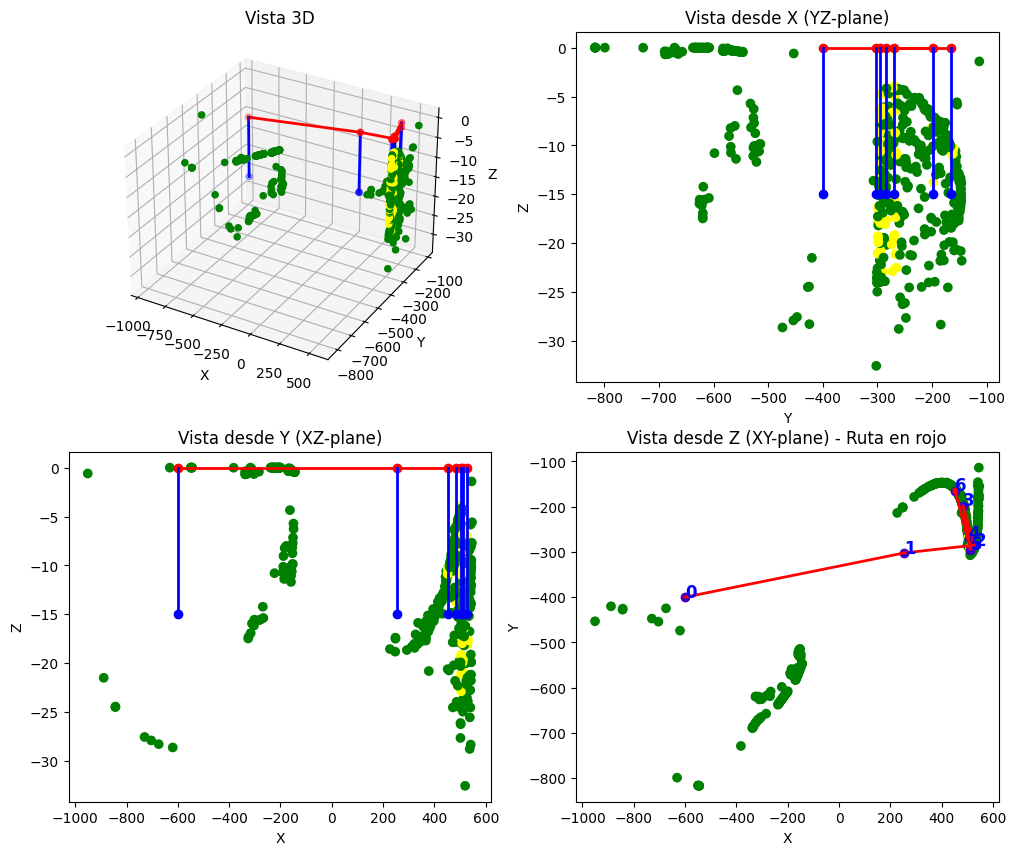

indice_tVec = 4
Tiempo de la ruta (s): 6275.837985024082
Tiempo del tramo (s): 1441.631142287123
Longitud recorrido (m): 2435.837985024114
INDICES DETECTADOS = 83.0


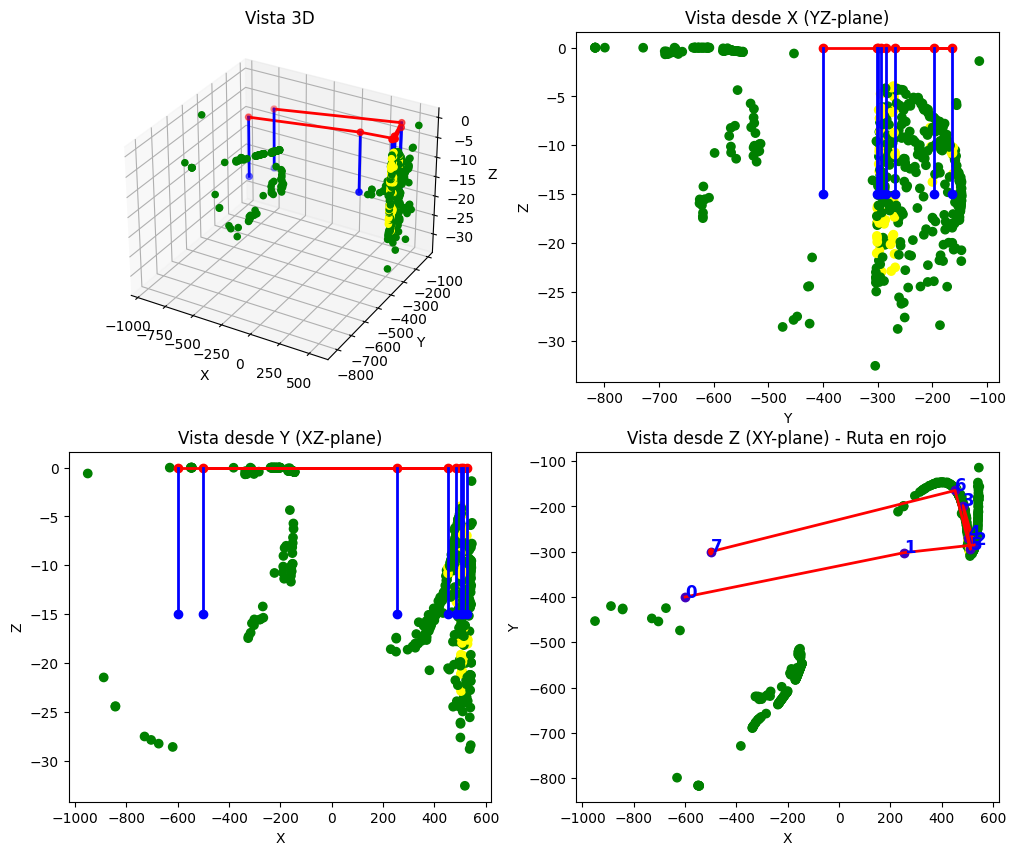

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []
longitud_recorrido = 0
for i in range(len(recorrido)):
    if (i==0):
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
    zeros.append(0)
    tAct = tiempo + longitud_recorrido/(problema.v_media*60) + t_medida*(i+1)
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 

    print(f"indice_tVec = {indice_tVec}")
    print(f"Tiempo de la ruta (s): {(tAct-tVec_min[0, 0])*60}")
    print(f"Tiempo del tramo (s): {((calcular_distancia(p1, p2)/(problema.v_media*60)) + t_medida)*60}")
    print(f"Longitud recorrido (m): {longitud_recorrido}")
    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]
    
    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 5  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    # if(i < len(tiempos_ruta)-1 ):
    #     ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
    #     ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    # else:
    #     ax4.set_xlim(min(x[0] - 100, min(x)), max(x[0] + 100, max(x)))
    #     ax4.set_ylim(min(y[0] - 100, min(y)), max(y[0] + 100, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta
